## Классификация MNIST



In [59]:
import numpy as np

import torch
from torch import nn
from torch.nn import functional as F

import torchvision
from torchvision.datasets import MNIST

from matplotlib import pyplot as plt
from IPython.display import clear_output
import tqdm

Давайте обратимся к классической задаче распознавания рукописных цифр. Мы будем работать с набором данных [MNIST](http://yann.lecun.com/exdb/mnist/). В этом задании мы воспользуемся всем датасетом целиком.

__Ваша основная задача: реализовать весь пайплайн обучения модели и добиться качества $\geq 92\%$ на тестовой выборке.__

Код для обучения модели в данном задании отсутствует. Присутствует лишь несколько тестов, которые помогут вам отладить свое решение. За примером можно обратиться к ноутбуку с первого занятия.

Мы настоятельно рекомендуем писать код «с нуля», лишь изредка подглядывая в готовые примеры, а не просто «копировать-вставлять». Это поможет вам в будущем.

Text(0.5, 1.0, 'Image label: 7')

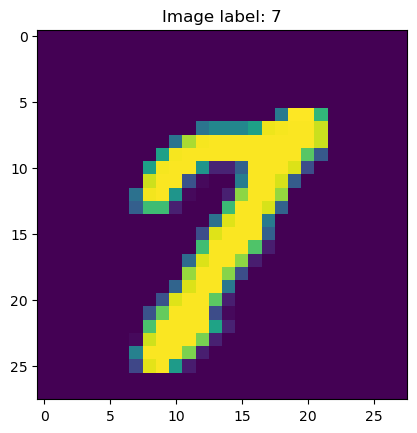

In [62]:
# do not change the code in the block below
# __________start of block__________

train_mnist_data = MNIST('.', train=True, transform=torchvision.transforms.ToTensor(), download=True)
test_mnist_data = MNIST('.', train=False, transform=torchvision.transforms.ToTensor(), download=True)


train_data_loader = torch.utils.data.DataLoader(
    train_mnist_data,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

test_data_loader = torch.utils.data.DataLoader(
    test_mnist_data,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

random_batch = next(iter(train_data_loader))
_image, _label = random_batch[0][0], random_batch[1][0]
plt.figure()
plt.imshow(_image.reshape(28, 28))
plt.title(f'Image label: {_label}')
# __________end of block__________

Постройте модель, представленную ниже. Пожалуйста, не создавайте чрезмерно сложную сеть — она не должна быть глубже четырёх слоёв (можно и меньше). Ваша основная задача — обучить модель и добиться как минимум 92% точности на тестовой выборке (hold-out выборке).

*Примечание: линейных слоёв и функций активации должно быть достаточно.*

__Обратите внимание, ваша модель должна быть представлена переменной `model`__

In [64]:
class Network(torch.nn.Module):
    def __init__(self, in_features, hidden_size, n_classes, n_layers, activation=torch.nn.ReLU):
        '''
        :param int in_features: Число входных признаков
        :param int hidden_size: Размер скрытых слоёв
        :param int n_classes: Число выходов сети
        :param int n_layers: Число слоёв в сети
        :param torch.nn.Module activation: Класс функции активации
        '''
        super().__init__()

        self.in_features = in_features
        self.hidden_size = hidden_size
        self.n_classes = n_classes
        self.n_layers = n_layers
        self.activation = activation

        layers = []

        if n_layers == 1:
            layers.append(torch.nn.Linear(in_features, n_classes))
        else:
            layers.append(torch.nn.Linear(in_features, hidden_size))
            layers.append(activation())
            
            for _ in range(n_layers - 2):
                layers.append(torch.nn.Linear(hidden_size, hidden_size))
                layers.append(activation())
            
            layers.append(torch.nn.Linear(hidden_size, n_classes))
        
        self.layers = torch.nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        '''
        Прямой проход по сети
        :param torch.Tensor x: Входной тензор размера [batch_size, in_features]
        :returns: Матрица логитов размера [batch_size, n_classes]
        '''
        return self.layers(x)

In [65]:
# Creating model instance
model = Network(
        in_features = 28*28,
        hidden_size = 8*8,
        n_classes = 10,
        n_layers = 3,
        activation = torch.nn.ReLU
)

Ниже доступны локальные тесты для проверки вашей модели:

In [67]:
# do not change the code in the block below
# __________start of block__________
assert model is not None, 'Please, use `model` variable to store your model'

try:
    x = random_batch[0].reshape(-1, 784)
    y = random_batch[1]

    # compute outputs given inputs, both are variables
    y_predicted = model(x)    
except Exception as e:
    print('Something is wrong with the model')
    raise e
    
    
assert y_predicted.shape[-1] == 10, 'Model should predict 10 logits/probas'

print('Everything seems fine!')
# __________end of block__________

Everything seems fine!


Обучите модель на обучающей выборке. Рекомендуем поэкспериментировать с различными оптимизаторами.


In [78]:
def training_loop(n_epochs, network, loss_fn, optimizer, train_loader, test_loader, device):
    '''
    :param int n_epochs: Число итераций оптимизации
    :param torch.nn.Module network: Нейронная сеть
    :param Callable loss_fn: Функция потерь
    :param torch.nn.Optimizer optimizer: Оптимизатор
    :param DataLoader train_loader: DataLoader для обучающей выборки
    :param DataLoader test_loader: DataLoader для тестовой выборки
    :param torch.Device device: Устройство для вычислений
    :returns: Списки значений функции потерь и точности
    '''
    
    train_losses, test_losses, train_accuracies, test_accuracies = [], [], [], []
    
    for epoch in tqdm.tqdm(range(n_epochs), total=n_epochs, leave=True):
        # Режим обучения
        network.train()
        
        total_train = 0
        correct_train = 0
        train_loss = 0
        
        # Проходим по всем батчам в train_loader
        for batch in train_loader:
            # batch[0] - изображения [batch_size, 1, 28, 28]
            # batch[1] - метки [batch_size]
            x, y = batch[0].to(device), batch[1].to(device)
            
            # Преобразуем формат: [batch_size, 1, 28, 28] -> [batch_size, 784]
            x = x.reshape(-1, 28*28)
            
            # Обнуляем градиенты
            optimizer.zero_grad()
            
            # Прямой проход
            outputs = network(x)
            loss = loss_fn(outputs, y)
            
            # Обратный проход
            loss.backward()
            optimizer.step()
            
            # Считаем статистику
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_train += y.size(0)
            correct_train += (predicted == y).sum().item()
        
        # Средние значения по эпохе
        train_acc = 100 * correct_train / total_train
        train_loss = train_loss / len(train_loader)
        train_accuracies.append(train_acc)
        train_losses.append(train_loss)

        # Оценка на тестовой выборке
        network.eval()
        total_test = 0
        correct_test = 0
        test_loss = 0
        
        with torch.no_grad():
            for batch in test_loader:
                x, y = batch[0].to(device), batch[1].to(device)
                x = x.reshape(-1, 28*28)
                outputs = network(x)
                test_loss += loss_fn(outputs, y).item()
                _, predicted = torch.max(outputs.data, 1)
                total_test += y.size(0)
                correct_test += (predicted == y).sum().item()
        
        test_acc = 100 * correct_test / total_test
        test_loss = test_loss / len(test_loader)
        test_accuracies.append(test_acc)
        test_losses.append(test_loss)

        if epoch % 10 == 0:
            print(f'Epoch {epoch}: '
                  f'Loss (Train/Test): {train_loss:.3f}/{test_loss:.3f}. '
                  f'Accuracy, % (Train/Test): {train_acc:.2f}/{test_acc:.2f}')

    return train_losses, test_losses, train_accuracies, test_accuracies

In [82]:
def init_weights(m):
    if isinstance(m, torch.nn.Linear):
        torch.nn.init.xavier_normal_(m.weight)

model.apply(init_weights)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

train_losses, test_losses, train_accs, test_accs = training_loop(
    n_epochs=10,  
    network=model, 
    loss_fn=torch.nn.CrossEntropyLoss(),  
    optimizer=torch.optim.Adam(model.parameters(), lr=0.001),
    train_loader=train_data_loader,
    test_loader=test_data_loader,
    device=device
)

 10%|████▍                                       | 1/10 [00:03<00:35,  3.99s/it]

Epoch 0: Loss (Train/Test): 0.268/0.135. Accuracy, % (Train/Test): 92.22/95.98


100%|███████████████████████████████████████████| 10/10 [00:39<00:00,  3.99s/it]


Также помните, что вы всегда можете обратиться к отличной [документации](https://pytorch.org/docs/stable/index.html) и [учебным материалам](https://pytorch.org/tutorials/).

Оценим качество классификации:

In [86]:
predicted_labels = []
real_labels = []
model.eval()
with torch.no_grad():
    for batch in train_data_loader:
        y_predicted = model(batch[0].reshape(-1, 784))
        predicted_labels.append(y_predicted.argmax(dim=1))
        real_labels.append(batch[1])

predicted_labels = torch.cat(predicted_labels)
real_labels = torch.cat(real_labels)
train_acc = (predicted_labels == real_labels).type(torch.FloatTensor).mean()

In [87]:
print(f'Neural network accuracy on train set: {train_acc:3.5}')

Neural network accuracy on train set: 0.99237


In [90]:
predicted_labels = []
real_labels = []
model.eval()
with torch.no_grad():
    for batch in test_data_loader:
        y_predicted = model(batch[0].reshape(-1, 784))
        predicted_labels.append(y_predicted.argmax(dim=1))
        real_labels.append(batch[1])

predicted_labels = torch.cat(predicted_labels)
real_labels = torch.cat(real_labels)
test_acc = (predicted_labels == real_labels).type(torch.FloatTensor).mean()

In [92]:
print(f'Neural network accuracy on test set: {test_acc:3.5}')

Neural network accuracy on test set: 0.9718


Проверка, что пороги пройдены:

In [95]:
assert test_acc >= 0.92, 'Test accuracy is below 0.92 threshold'
assert train_acc >= 0.91, 'Train accuracy is below 0.91 while test accuracy is fine. We recommend to check your model and data flow'

Обращаем внимане, код ниже предполагает, что ваша модель имеет содержится в переменной `model`, а файл `hw_mnist_data_dict.npy` находится в той же директории, что и ноутбук (он доступен в репозитории).

In [98]:
# do not change the code in the block below
# __________start of block__________
import os
import json
assert os.path.exists('hw_mnist_data_dict.npy'), 'Please, download `hw_mnist_data_dict.npy` and place it in the working directory'

def get_predictions(model, eval_data, step=10):
    
    predicted_labels = []
    model.eval()
    with torch.no_grad():
        for idx in range(0, len(eval_data), step):
            y_predicted = model(eval_data[idx:idx+step].reshape(-1, 784))
            predicted_labels.append(y_predicted.argmax(dim=1))
    
    predicted_labels = torch.cat(predicted_labels).numpy()
    predicted_labels = ','.join([str(x) for x in list(predicted_labels)])
    return predicted_labels

loaded_data_dict = np.load('hw_mnist_data_dict.npy', allow_pickle=True)

submission_dict = {
    'train': get_predictions(model, torch.FloatTensor(loaded_data_dict.item()['train'])),
    'test': get_predictions(model, torch.FloatTensor(loaded_data_dict.item()['test']))
}

with open('submission_dict_mnist_task_1.json', 'w') as iofile:
    json.dump(submission_dict, iofile)
print('File saved to `submission_dict_mnist_task_1.json`')
# __________end of block__________

File saved to `submission_dict_mnist_task_1.json`


### Сдача задания
Сдайте сгенерированный файл в соответствующую задачу в соревновании, а именно:
    
* `submission_dict_mnist_task_1.json` в задачу Warmup (hw_mnist)

На этом задание завершено. Поздравляем!